## Import libraries

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Load Dataset 

In [25]:
df = pd.read_csv("data/HousePricePrediction.csv")

### Data Exploration

In [26]:
df.head()
df.shape

(2919, 13)

In [27]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

features which containing null values:
- MSZoning, Exterior1st, BsmtFinSf2, TotalBsmtSF => we will **drop null** values these all
- SalePrice : **fill null** by its **mean** value

## Data Preprocessing

### Data Cleaning

In [28]:
# drop Id => because it doesn't contribute in price
df.drop("Id", axis=1, inplace=True)

# Filling SalePrice empty values with their mean values 
df["SalePrice"] = df["SalePrice"].fillna(df["SalePrice"].mean())

df.dropna(inplace=True)

In [29]:
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

Now no any null value in dataset

### Encoding Categorical Varibales

In [30]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 2913 entries, 0 to 2918
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    2913 non-null   int64  
 1   MSZoning      2913 non-null   str    
 2   LotArea       2913 non-null   int64  
 3   LotConfig     2913 non-null   str    
 4   BldgType      2913 non-null   str    
 5   OverallCond   2913 non-null   int64  
 6   YearBuilt     2913 non-null   int64  
 7   YearRemodAdd  2913 non-null   int64  
 8   Exterior1st   2913 non-null   str    
 9   BsmtFinSF2    2913 non-null   float64
 10  TotalBsmtSF   2913 non-null   float64
 11  SalePrice     2913 non-null   float64
dtypes: float64(3), int64(5), str(4)
memory usage: 295.9 KB


categorical variables in dataset: **MSZoning, LotConfig, BldgType, Exterior1st** 

In [31]:
# one hot encoding
cols = ["MSZoning", "LotConfig", "BldgType", "Exterior1st"]

df = pd.get_dummies(df, columns=cols, drop_first=True, dtype=int)

In [32]:
df["HouseAge"] = 2025 - df["YearBuilt"]
df["RemodelAge"] = 2025 - df["YearRemodAdd"]
df.drop(["YearBuilt", "YearRemodAdd"], axis=1, inplace=True)

## Train-Test Split

In [33]:
X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training - Linear Regression

In [34]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
pred_val = model.predict(X_test)

## Model Evaluation

In [36]:
# Evaluation

print("r2_score: ", r2_score(y_test, pred_val)) # Show how well the model explain the variance in hosue price
print("MAE: ", mean_absolute_error(y_test, pred_val))
print("MSE: ", mean_squared_error(y_test, pred_val))
print("RMSE: ", root_mean_squared_error(y_test, pred_val)) # 
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_val)) # Percentage error in prediction

r2_score:  0.34692237851875896
MAE:  32690.891525374307
MSE:  2381166211.4167137
RMSE:  48797.19470847391
MAPE:  0.20016996577116625


- Model Achived **R2_score of 0.34**, Which indicates that it explain around **34% of variance in house prices**.
- Mean Absolute Percentage Error(MAPE) is approximatley 20% , meaning the model prediction deviate by 20% on average.

I know performation of this **model is very low** - but I think it must acceptable beacuse I'm begginar and using **basic Linear Regression**

---

## Feature Scaling Experiment

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Model training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Model evaluation
print("r2_score: ", r2_score(y_test, y_pred)) # Show how well the model explain the variance in hosue price
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred)) # 
print("MAPE: ", mean_absolute_percentage_error(y_test, y_pred))

r2_score:  0.34692237851875585
MAE:  32690.891525374318
MSE:  2381166211.416725
RMSE:  48797.194708474024
MAPE:  0.2001699657711669


After Scaling No any improvement - all Evaluation value is similar to previous

## Conclusion

In this assignment, we built a basic Machine Learning pipeline for predicting house prices.

Key steps included:

- Data Cleaning
- Categorical feature encoding
- Training a Linear Regreesion model
- Evaluating model performance

This exercise helped in understanding the complete workflow of supervised learning regression model.

## Visualization

Text(0.5, 1.0, 'Actual vs Predicted House Prices')

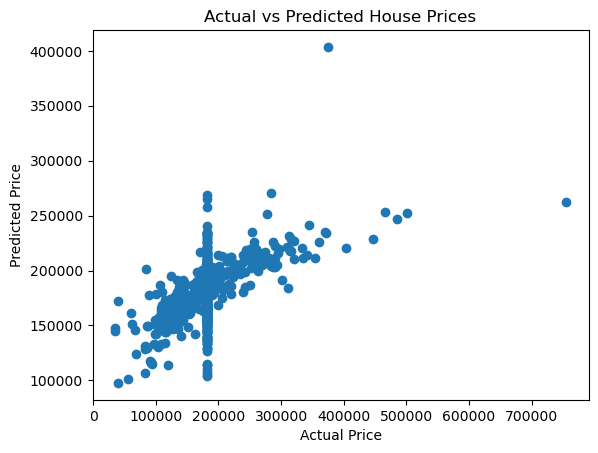

In [39]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")